In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
DATA_PATH = Path("../Data")

In [3]:
## parking_availabilities

In [4]:
p_av = pd.read_parquet(DATA_PATH / "parking_availabilities.parquet")

In [5]:
p_av.head()

,id,parking_id,spaces_left,trend,measured_at,created_at,updated_at
0,1,4,0,0,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.203000+00:00,2025-02-03 07:51:16.203000+00:00
1,2,2,4,0,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.217000+00:00,2025-02-03 07:51:16.217000+00:00
2,3,5,0,0,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.228000+00:00,2025-02-03 07:51:16.228000+00:00
3,4,6,169,-2,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.237000+00:00,2025-02-03 07:51:16.237000+00:00
4,5,7,57,-1,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.246000+00:00,2025-02-03 07:51:16.246000+00:00


In [6]:
p_av.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826529 entries, 0 to 1826528
Data columns (total 7 columns):
 #   Column       Dtype              
---  ------       -----              
 0   id           int64              
 1   parking_id   int64              
 2   spaces_left  int64              
 3   trend        int64              
 4   measured_at  datetime64[ns, UTC]
 5   created_at   datetime64[ns, UTC]
 6   updated_at   datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](3), int64(4)
memory usage: 97.5 MB


In [7]:
p_av.describe(include='all')

,id,parking_id,spaces_left,trend,measured_at,created_at,updated_at
count,1.826529e+06,1.826529e+06,1.826529e+06,1.826529e+06,1826529,1826529,1826529
mean,9.132737e+05,4.800000e+00,1.001074e+02,-1.261907e-01,2025-07-10 13:13:23.323944192+00:00,2025-07-10 13:13:27.569040384+00:00,2025-07-10 13:13:27.569061376+00:00
min,1.000000e+00,2.000000e+00,-3.600000e+01,-3.700000e+01,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.203000+00:00,2025-02-03 07:51:16.203000+00:00
25%,4.566330e+05,4.000000e+00,3.700000e+01,0.000000e+00,2025-04-29 16:38:01+00:00,2025-04-29 16:38:06.140000+00:00,2025-04-29 16:38:06.140000+00:00
50%,9.132650e+05,5.000000e+00,7.200000e+01,0.000000e+00,2025-07-11 15:43:01+00:00,2025-07-11 15:43:06.048999936+00:00,2025-07-11 15:43:06.048999936+00:00
75%,1.369925e+06,6.000000e+00,1.830000e+02,0.000000e+00,2025-09-22 02:17:01+00:00,2025-09-22 02:17:03.670000128+00:00,2025-09-22 02:17:03.670000128+00:00
max,1.826557e+06,7.000000e+00,2.670000e+02,4.300000e+01,2025-12-07 14:53:01+00:00,2025-12-07 14:53:06.341000+00:00,2025-12-07 14:53:06.341000+00:00
std,5.272840e+05,1.720466e+00,8.639102e+01,5.631645e-01,NaN,NaN,NaN


In [8]:
# zlicz nany w kolumnach
p_av.isna().sum()

id             0
parking_id     0
spaces_left    0
trend          0
measured_at    0
created_at     0
updated_at     0
dtype: int64

In [9]:
p_av.duplicated().sum()

0

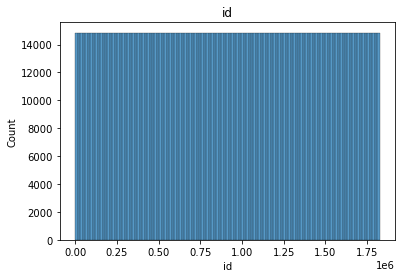

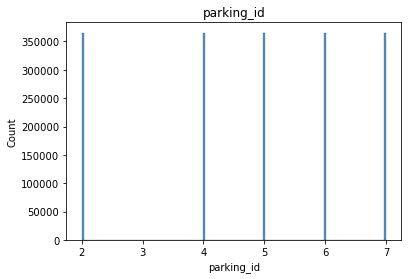

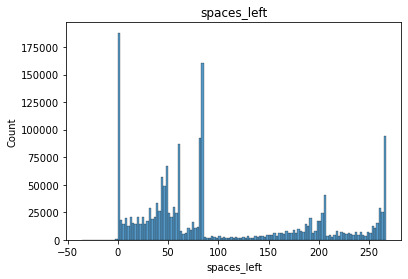

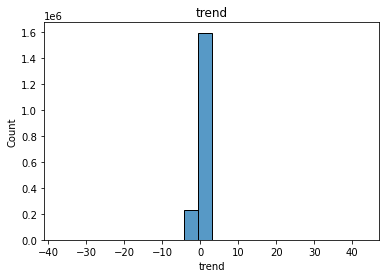

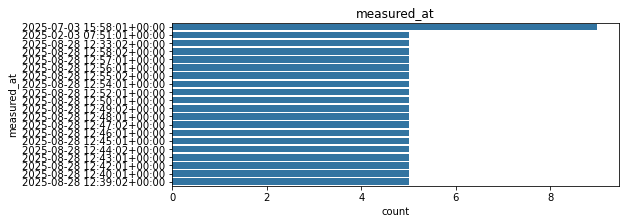

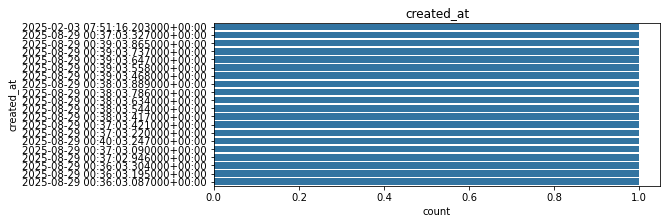

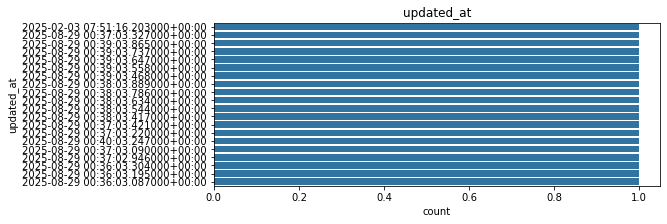

In [15]:

def df_plot(df):
    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(exclude=np.number).columns

    for col in num_cols:
        plt.figure()
        # Disable KDE due to compatibility issue between old matplotlib (3.5.1) and new pandas (2.3.3)
        sns.histplot(df[col].dropna(), kde=False)
        plt.title(col)
        plt.xlabel(col)
        plt.show()

    for col in cat_cols:
        plt.figure(figsize=(8,3))
        sns.countplot(data=df, y=col, order=df[col].value_counts().index[:20])
        plt.title(col)
        plt.show()

df_plot(p_av)


### Time Analysis

In [16]:
# Convert timestamps to datetime
p_av['measured_at'] = pd.to_datetime(p_av['measured_at'])
p_av['created_at'] = pd.to_datetime(p_av['created_at'])

# Extract time components
p_av['hour'] = p_av['measured_at'].dt.hour
p_av['day_of_week'] = p_av['measured_at'].dt.dayofweek
p_av['day_name'] = p_av['measured_at'].dt.day_name()
p_av['date'] = p_av['measured_at'].dt.date

p_av.head()

,id,parking_id,spaces_left,trend,measured_at,created_at,updated_at,hour,day_of_week,day_name,date
0,1,4,0,0,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.203000+00:00,2025-02-03 07:51:16.203000+00:00,7,0,Monday,2025-02-03
1,2,2,4,0,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.217000+00:00,2025-02-03 07:51:16.217000+00:00,7,0,Monday,2025-02-03
2,3,5,0,0,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.228000+00:00,2025-02-03 07:51:16.228000+00:00,7,0,Monday,2025-02-03
3,4,6,169,-2,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.237000+00:00,2025-02-03 07:51:16.237000+00:00,7,0,Monday,2025-02-03
4,5,7,57,-1,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.246000+00:00,2025-02-03 07:51:16.246000+00:00,7,0,Monday,2025-02-03


In [17]:
# Time range of the data
print(f"Data range: {p_av['measured_at'].min()} to {p_av['measured_at'].max()}")
print(f"Total days: {(p_av['measured_at'].max() - p_av['measured_at'].min()).days}")
print(f"Number of unique dates: {p_av['date'].nunique()}")
print(f"Number of unique parking locations: {p_av['parking_id'].nunique()}")

Data range: 2025-02-03 07:51:01+00:00 to 2025-12-07 14:53:01+00:00
Total days: 307
Number of unique dates: 301
Number of unique parking locations: 5


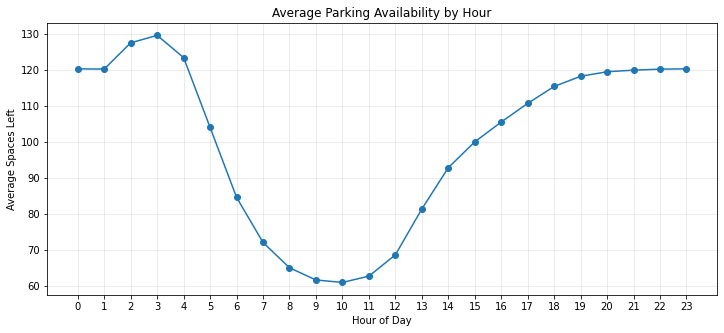

In [21]:
# Hourly patterns
plt.figure(figsize=(12, 5))
hourly_avg = p_av.groupby('hour')['spaces_left'].mean()
plt.plot(hourly_avg.index.to_numpy(), hourly_avg.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average Spaces Left')
plt.title('Average Parking Availability by Hour')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.show()

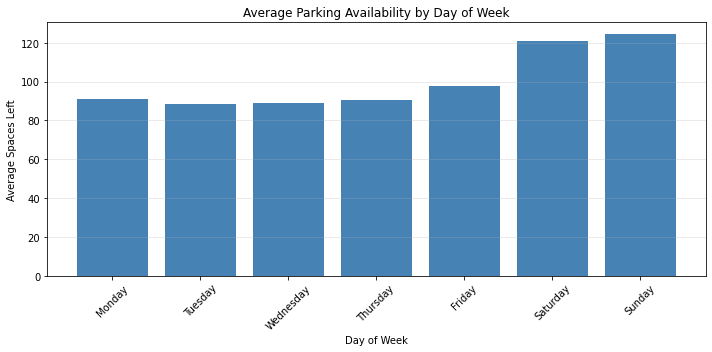

In [19]:
# Day of week patterns
plt.figure(figsize=(10, 5))
day_avg = p_av.groupby('day_name')['spaces_left'].mean()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_avg = day_avg.reindex(day_order)
plt.bar(day_avg.index, day_avg.values, color='steelblue')
plt.xlabel('Day of Week')
plt.ylabel('Average Spaces Left')
plt.title('Average Parking Availability by Day of Week')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Parking Location Analysis

In [20]:
# Average availability by parking location
parking_stats = p_av.groupby('parking_id').agg({
    'spaces_left': ['mean', 'std', 'min', 'max'],
    'id': 'count'
}).round(2)
parking_stats.columns = ['avg_spaces', 'std_spaces', 'min_spaces', 'max_spaces', 'num_records']
parking_stats = parking_stats.sort_values('avg_spaces', ascending=False)
parking_stats

,avg_spaces,std_spaces,min_spaces,max_spaces,num_records
parking_id,,,,,
6,223.08,65.96,0,267,365306
4,139.04,71.53,-36,207,365305
7,74.81,17.07,7,84,365306
2,36.44,23.39,-15,61,365306
5,27.16,18.92,-11,49,365306


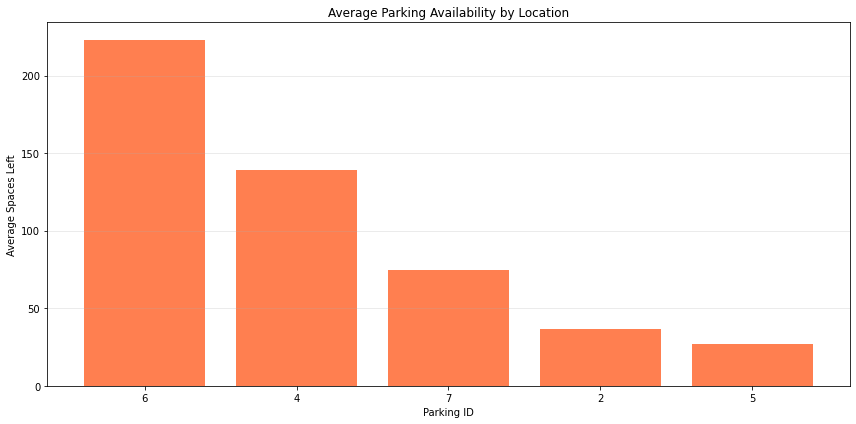

In [22]:
# Visualize availability by parking location
plt.figure(figsize=(12, 6))
parking_avg = p_av.groupby('parking_id')['spaces_left'].mean().sort_values(ascending=False)
plt.bar([str(x) for x in parking_avg.index], parking_avg.values, color='coral')
plt.xlabel('Parking ID')
plt.ylabel('Average Spaces Left')
plt.title('Average Parking Availability by Location')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

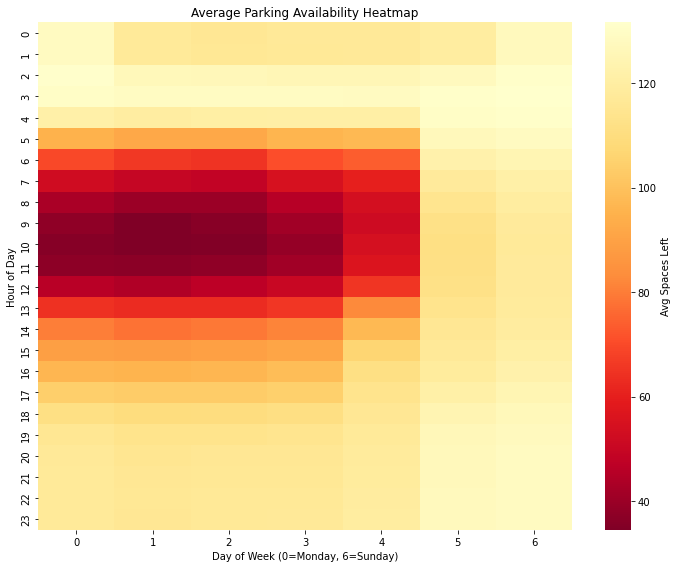

In [23]:
# Heatmap: Hour vs Day of Week for average spaces
pivot_table = p_av.pivot_table(
    values='spaces_left', 
    index='hour', 
    columns='day_of_week', 
    aggfunc='mean'
)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, cmap='YlOrRd_r', annot=False, fmt='.0f', cbar_kws={'label': 'Avg Spaces Left'})
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Hour of Day')
plt.title('Average Parking Availability Heatmap')
plt.tight_layout()
plt.show()

### Trend Analysis

In [24]:
# Analyze trend values
print("Trend value distribution:")
print(p_av['trend'].value_counts().sort_index())
print(f"\nTrend interpretation: positive = more spaces becoming available, negative = spaces being filled")

Trend value distribution:
trend
-37          6
-36          3
-32          3
-16          7
-13         93
-12         11
-11          7
-10         24
-9          44
-8          45
-7         108
-6         387
-5        1130
-4        2283
-3        4848
-2       16216
-1      203610
 0     1571776
 1       20803
 2        2819
 3         600
 4         388
 5         299
 6         216
 7         172
 8         148
 9         119
 10        124
 11         72
 12         94
 13         19
 14          2
 15          5
 16          6
 17          9
 21          4
 28          5
 32          5
 34          3
 37         11
 42          3
 43          2
Name: count, dtype: int64

Trend interpretation: positive = more spaces becoming available, negative = spaces being filled


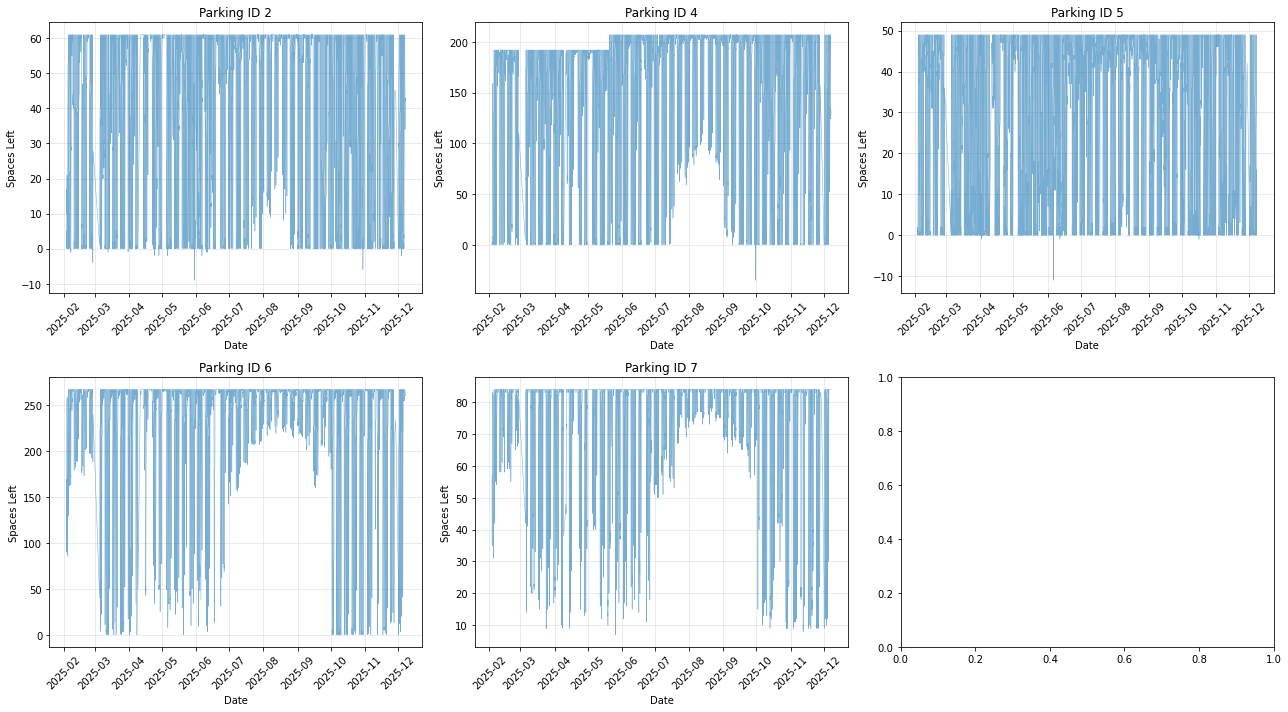

In [25]:
# Time series plot for each parking location
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, parking_id in enumerate(sorted(p_av['parking_id'].unique())):
    parking_data = p_av[p_av['parking_id'] == parking_id].sort_values('measured_at')
    # Sample data if too large (plot every 10th point for clarity)
    if len(parking_data) > 1000:
        parking_data = parking_data.iloc[::10]
    
    axes[idx].plot(parking_data['measured_at'].to_numpy(), parking_data['spaces_left'].to_numpy(), alpha=0.6, linewidth=0.5)
    axes[idx].set_title(f'Parking ID {parking_id}')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Spaces Left')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Occupancy Analysis

In [26]:
# Check for full occupancy (0 spaces)
full_occupancy = (p_av['spaces_left'] == 0).sum()
total_records = len(p_av)
print(f"Records with full occupancy (0 spaces): {full_occupancy} ({full_occupancy/total_records*100:.2f}%)")

# Full occupancy by parking location
full_by_parking = p_av[p_av['spaces_left'] == 0].groupby('parking_id').size()
total_by_parking = p_av.groupby('parking_id').size()
full_pct = (full_by_parking / total_by_parking * 100).round(2)
print("\nFull occupancy percentage by parking:")
print(full_pct.sort_values(ascending=False))

Records with full occupancy (0 spaces): 145480 (7.96%)

Full occupancy percentage by parking:
parking_id
5    15.89
2    15.65
4     7.92
6     0.36
7      NaN
dtype: float64


---
## Feature Engineering & Prediction Analysis

In [39]:
# Merge parking metadata with availability data
p_av_full = p_av.merge(parkings[['id', 'name', 'places', 'address']], 
                        left_on='parking_id', right_on='id', 
                        suffixes=('', '_parking'))

# Calculate occupancy rate
p_av_full['occupancy_rate'] = (p_av_full['places'] - p_av_full['spaces_left']) / p_av_full['places'] * 100
p_av_full.head()

,id,parking_id,spaces_left,trend,measured_at,created_at,updated_at,hour,day_of_week,day_name,date,id_parking,name,places,address,occupancy_rate
0,1,4,0,0,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.203000+00:00,2025-02-03 07:51:16.203000+00:00,7,0,Monday,2025-02-03,4,Parking Wrońskiego,207,"Hoene-Wrońskiego 10, 50-376 Wrocław",100.000000
1,2,2,4,0,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.217000+00:00,2025-02-03 07:51:16.217000+00:00,7,0,Monday,2025-02-03,2,Polinka,54,"wybrzeże Stanisława Wyspiańskiego 25, 50-370 W...",92.592593
2,3,5,0,0,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.228000+00:00,2025-02-03 07:51:16.228000+00:00,7,0,Monday,2025-02-03,5,D20 - D21,76,"Janiszewskiego 8, 50-372 Wrocław\r\n",100.000000
3,4,6,169,-2,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.237000+00:00,2025-02-03 07:51:16.237000+00:00,7,0,Monday,2025-02-03,6,GEO LO1 Geocentrum,301,"Na Grobli 15, 50-421 Wrocław\r\n",43.853821
4,5,7,57,-1,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.246000+00:00,2025-02-03 07:51:16.246000+00:00,7,0,Monday,2025-02-03,7,Architektura,75,"Bolesława Prusa 53/55, 50-317 Wrocław\r\n",24.000000


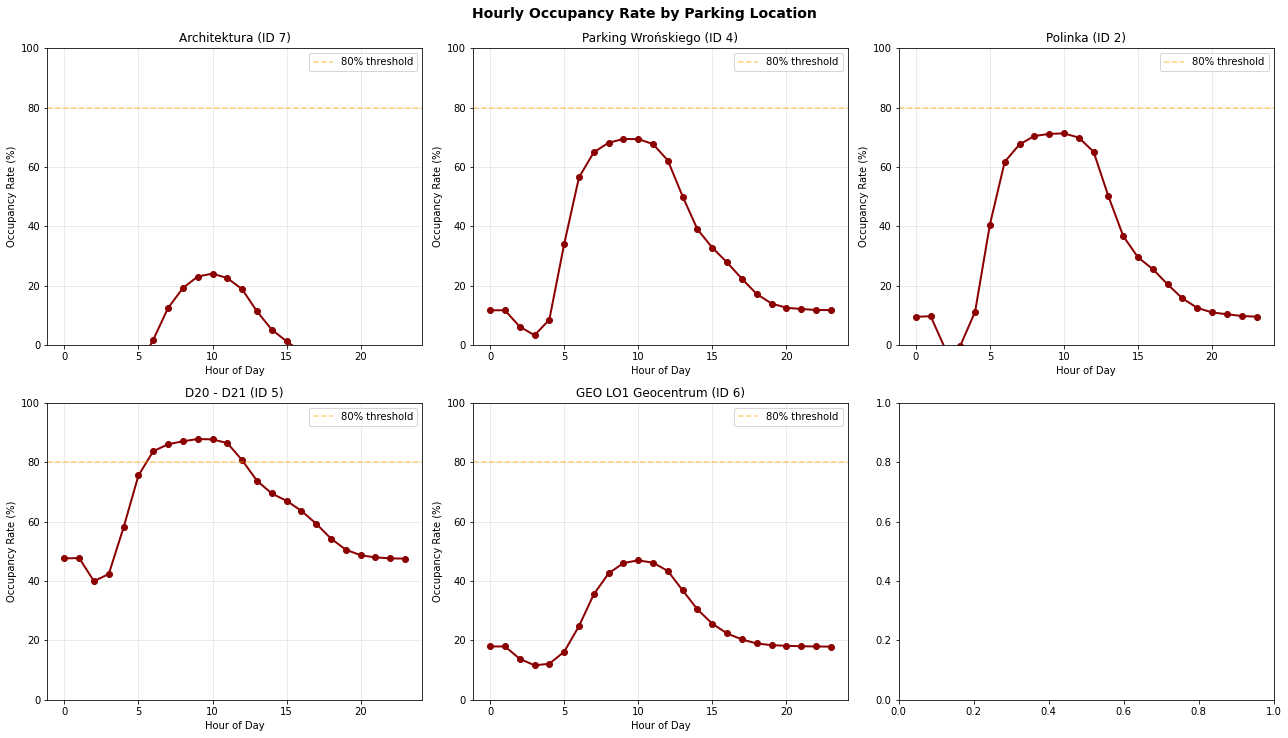

In [40]:
# Analyze occupancy by parking and time
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (parking_id, parking_name) in enumerate(parkings[['id', 'name']].values):
    if parking_id in p_av_full['parking_id'].unique():
        data = p_av_full[p_av_full['parking_id'] == parking_id]
        hourly_occ = data.groupby('hour')['occupancy_rate'].mean()
        
        axes[idx].plot(hourly_occ.index.to_numpy(), hourly_occ.values, marker='o', linewidth=2, color='darkred')
        axes[idx].set_title(f'{parking_name} (ID {parking_id})')
        axes[idx].set_xlabel('Hour of Day')
        axes[idx].set_ylabel('Occupancy Rate (%)')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_ylim(0, 100)
        axes[idx].axhline(y=80, color='orange', linestyle='--', alpha=0.5, label='80% threshold')
        axes[idx].legend()

plt.tight_layout()
plt.suptitle('Hourly Occupancy Rate by Parking Location', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### Impact of Events on Parking

In [41]:
# Convert event times and create event features
pwr_events['start'] = pd.to_datetime(pwr_events['start'])
pwr_events['end'] = pd.to_datetime(pwr_events['end'])
pwr_events['event_date'] = pwr_events['start'].dt.date
pwr_events['event_hour'] = pwr_events['start'].dt.hour
pwr_events['event_duration_hours'] = (pwr_events['end'] - pwr_events['start']).dt.total_seconds() / 3600

print(f"Total events: {len(pwr_events)}")
print(f"Date range: {pwr_events['start'].min()} to {pwr_events['end'].max()}")
print(f"\nAverage event duration: {pwr_events['event_duration_hours'].mean():.2f} hours")
print(f"Most common event locations:")
print(pwr_events['location'].value_counts().head(10))

Total events: 1065
Date range: 2012-10-16 17:00:00+00:00 to 2040-06-14 00:00:00+00:00

Average event duration: 27.17 hours
Most common event locations:
location
                                                                                                   868
Strefa Kultury Studenckiej, Hoene-Wrońskiego 10, 50-376 Wrocław, Polska                             11
Politechnika Wrocławska, wybrzeże Stanisława Wyspiańskiego 27, 50-370 Wrocław, Polska                7
Klub "Od Zmierzchu do Świtu"                                                                         7
Ośrodek Wypoczynkowy Marysieńka, Wodna 3, 57-343 Lewin Kłodzki, Polska                               5
Klubokawiarnia SKS                                                                                   4
C-13                                                                                                 4
Students Club Bajer, Edwarda Wittiga 6, 50-438 Wrocław, Poland                                       4
SKS            

In [42]:
# Create feature: is there an event happening at each measurement time?
p_av_full['date'] = p_av_full['measured_at'].dt.date
p_av_full['datetime'] = p_av_full['measured_at']

# For each row, check if there's an active event
def has_active_event(row):
    return pwr_events[(pwr_events['start'] <= row['datetime']) & (pwr_events['end'] >= row['datetime'])].shape[0] > 0

p_av_full['has_event'] = p_av_full.apply(has_active_event, axis=1)

print(f"Percentage of measurements during events: {p_av_full['has_event'].mean() * 100:.2f}%")
print(f"\nOccupancy rate comparison:")
print(f"During events: {p_av_full[p_av_full['has_event']]['occupancy_rate'].mean():.2f}%")
print(f"Without events: {p_av_full[~p_av_full['has_event']]['occupancy_rate'].mean():.2f}%")

Percentage of measurements during events: 29.38%

Occupancy rate comparison:
During events: 37.88%
Without events: 28.35%


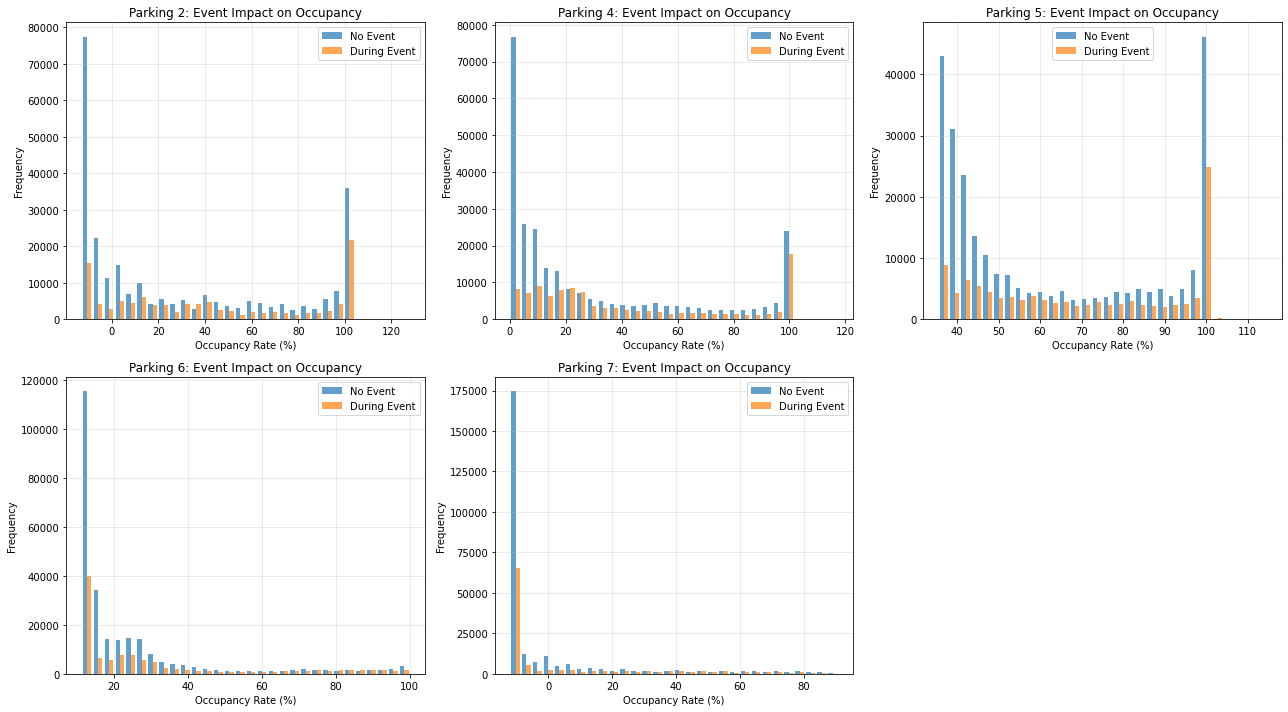

In [48]:
# Visualize impact of events by parking
unique_parkings = sorted(p_av_full['parking_id'].unique())
n_parkings = len(unique_parkings)

# Create appropriate grid size
n_cols = 3
n_rows = (n_parkings + n_cols - 1) // n_cols  # Ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, parking_id in enumerate(unique_parkings):
    parking_data = p_av_full[p_av_full['parking_id'] == parking_id]
    
    event_data = parking_data[parking_data['has_event']]['occupancy_rate']
    no_event_data = parking_data[~parking_data['has_event']]['occupancy_rate']
    
    axes[idx].hist([no_event_data, event_data], bins=30, label=['No Event', 'During Event'], alpha=0.7)
    axes[idx].set_title(f'Parking {parking_id}: Event Impact on Occupancy')
    axes[idx].set_xlabel('Occupancy Rate (%)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(n_parkings, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Student Activity Correlation

In [49]:
# Prepare SKS user activity data
sks_users['timestamp'] = pd.to_datetime(sks_users['timestamp'])
sks_users['date'] = sks_users['timestamp'].dt.date

print(f"SKS user data range: {sks_users['timestamp'].min()} to {sks_users['timestamp'].max()}")
print(f"Total measurements: {len(sks_users)}")

# Aggregate student activity by date
daily_activity = sks_users.groupby('date').agg({
    'moving_average_21': 'mean',
    'active_users': 'mean'
}).reset_index()

print(f"\nDaily active users stats:")
print(daily_activity['active_users'].describe())

KeyError: 'timestamp'

In [ ]:
# Merge student activity with parking data (by date)
p_av_with_users = p_av_full.merge(
    daily_activity[['date', 'moving_average_21', 'active_users']], 
    on='date', 
    how='left'
)

print(f"Merged data shape: {p_av_with_users.shape}")
print(f"Missing student activity data: {p_av_with_users['active_users'].isna().sum()} rows")

# Calculate correlation between student activity and occupancy
correlation = p_av_with_users[['occupancy_rate', 'moving_average_21', 'active_users']].corr()
print("\nCorrelation matrix:")
print(correlation)

In [ ]:
# Visualize relationship between student activity and parking occupancy
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter plot: active users vs occupancy rate
sample_data = p_av_with_users.dropna(subset=['active_users']).sample(min(10000, len(p_av_with_users)))
axes[0].scatter(sample_data['active_users'], sample_data['occupancy_rate'], alpha=0.3, s=10)
axes[0].set_xlabel('Active Users')
axes[0].set_ylabel('Occupancy Rate (%)')
axes[0].set_title('Student Activity vs Parking Occupancy')
axes[0].grid(True, alpha=0.3)

# Time series: daily average
daily_comparison = p_av_with_users.groupby('date').agg({
    'occupancy_rate': 'mean',
    'active_users': 'mean'
}).reset_index()

ax1 = axes[1]
ax2 = ax1.twinx()

dates = [pd.to_datetime(d) for d in daily_comparison['date']]
ax1.plot(dates, daily_comparison['occupancy_rate'], 'b-', alpha=0.7, label='Occupancy Rate')
ax2.plot(dates, daily_comparison['active_users'], 'r-', alpha=0.7, label='Active Users')

ax1.set_xlabel('Date')
ax1.set_ylabel('Avg Occupancy Rate (%)', color='b')
ax2.set_ylabel('Avg Active Users', color='r')
ax1.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')
ax1.set_title('Daily Trends: Occupancy vs Student Activity')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Feature Correlation Analysis for Prediction

In [ ]:
# Create comprehensive feature correlation matrix
feature_cols = ['spaces_left', 'occupancy_rate', 'hour', 'day_of_week', 
                'has_event', 'moving_average_21', 'active_users']

correlation_matrix = p_av_with_users[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.3f')
plt.title('Feature Correlation Matrix for Prediction', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\nKey correlations with spaces_left (target variable):")
print(correlation_matrix['spaces_left'].sort_values(ascending=False))

In [ ]:
# Analyze correlations for each parking location separately
print("Correlation with spaces_left by parking location:\n")

for parking_id in sorted(p_av_with_users['id'].unique()):
    parking_data = p_av_with_users[p_av_with_users['id'] == parking_id]
    corr = parking_data[feature_cols].corr()['spaces_left'].sort_values(ascending=False)
    
    print(f"\n{'='*50}")
    print(f"Parking {parking_id} (Capacity: {parking_data['places'].iloc[0]})")
    print(f"{'='*50}")
    print(corr.to_string())

### Additional Predictive Features

In [ ]:
# Create additional time-based features for prediction
p_av_with_users['is_weekend'] = p_av_with_users['day_of_week'].isin([5, 6]).astype(int)
p_av_with_users['is_business_hours'] = p_av_with_users['hour'].between(7, 18).astype(int)
p_av_with_users['is_peak_hour'] = p_av_with_users['hour'].between(8, 12).astype(int)
p_av_with_users['month'] = p_av_with_users['measured_at'].dt.month
p_av_with_users['week_of_year'] = p_av_with_users['measured_at'].dt.isocalendar().week

# Lag features - previous occupancy
p_av_with_users = p_av_with_users.sort_values(['id', 'measured_at'])
p_av_with_users['occupancy_lag_1h'] = p_av_with_users.groupby('id')['occupancy_rate'].shift(2)  # 2 measurements = 1 hour
p_av_with_users['occupancy_lag_3h'] = p_av_with_users.groupby('id')['occupancy_rate'].shift(6)  # 6 measurements = 3 hours
p_av_with_users['occupancy_lag_1d'] = p_av_with_users.groupby('id')['occupancy_rate'].shift(48)  # 48 measurements = 1 day

print("Additional features created:")
print("- is_weekend: Binary indicator for Saturday/Sunday")
print("- is_business_hours: Binary indicator for 7 AM - 6 PM")
print("- is_peak_hour: Binary indicator for 8 AM - 12 PM (highest occupancy)")
print("- month: Month of the year")
print("- week_of_year: Week number in the year")
print("- occupancy_lag_1h: Occupancy rate 1 hour ago")
print("- occupancy_lag_3h: Occupancy rate 3 hours ago")
print("- occupancy_lag_1d: Occupancy rate 1 day ago (same time yesterday)")

print(f"\n Sample of new features:")
print(p_av_with_users[['measured_at', 'id', 'occupancy_rate', 'is_weekend', 
                        'is_peak_hour', 'occupancy_lag_1h', 'occupancy_lag_1d']].head(10))

In [ ]:
# Correlation of new features with target
new_features = ['is_weekend', 'is_business_hours', 'is_peak_hour', 'month', 
                'occupancy_lag_1h', 'occupancy_lag_3h', 'occupancy_lag_1d']

# Filter to rows with lag features available
data_with_lags = p_av_with_users.dropna(subset=['occupancy_lag_1d'])

feature_importance = data_with_lags[new_features + ['spaces_left']].corr()['spaces_left'].drop('spaces_left')

plt.figure(figsize=(10, 6))
feature_importance.sort_values().plot(kind='barh')
plt.title('Correlation of Additional Features with spaces_left')
plt.xlabel('Correlation Coefficient')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Feature correlations with spaces_left:")
print(feature_importance.sort_values(ascending=False))

### Data Quality & Readiness for Prediction

In [ ]:
# Check data completeness and missing values
print("="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)

print("\n1. Missing values in key features:")
all_features = ['spaces_left', 'hour', 'day_of_week', 'has_event', 
                'moving_average_21', 'active_users', 'is_weekend', 
                'is_peak_hour', 'occupancy_lag_1h', 'occupancy_lag_1d']

missing_summary = p_av_with_users[all_features].isna().sum()
missing_pct = (missing_summary / len(p_av_with_users) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n2. Data availability by parking location:")
for parking_id in sorted(p_av_with_users['id'].unique()):
    parking_data = p_av_with_users[p_av_with_users['id'] == parking_id]
    print(f"\nParking {parking_id}:")
    print(f"  Total measurements: {len(parking_data)}")
    print(f"  Date range: {parking_data['measured_at'].min()} to {parking_data['measured_at'].max()}")
    print(f"  Missing spaces_left: {parking_data['spaces_left'].isna().sum()}")

print("\n3. Temporal gaps analysis:")
for parking_id in sorted(p_av_with_users['id'].unique()):
    parking_data = p_av_with_users[p_av_with_users['id'] == parking_id].sort_values('measured_at')
    time_diffs = parking_data['measured_at'].diff()
    expected_diff = pd.Timedelta(minutes=30)
    gaps = time_diffs[time_diffs > expected_diff * 1.5]
    
    if len(gaps) > 0:
        print(f"\nParking {parking_id}: {len(gaps)} gaps larger than expected")
        print(f"  Largest gap: {gaps.max()}")
    else:
        print(f"\nParking {parking_id}: No significant gaps")

---
## parkings

In [27]:
parkings = pd.read_parquet(DATA_PATH / "parkings.parquet")
parkings

,id,symbol,type,name,open_hour,close_hour,places,geo_lan,geo_lat,is_active,is_visible,address,created_at,updated_at
0,7,E01,O,Architektura,06:00:00,22:30:00,75,17.054167,51.118736,True,True,"Bolesława Prusa 53/55, 50-317 Wrocław\r\n",2025-02-03 07:51:16.241000+00:00,2025-12-06 19:46:06.731000+00:00
1,4,WRO,O,Parking Wrońskiego,06:00:00,22:00:00,207,17.055565,51.108963,True,True,"Hoene-Wrońskiego 10, 50-376 Wrocław",2025-02-03 07:51:16.185000+00:00,2025-12-06 19:46:06.218000+00:00
2,2,C13,O,Polinka,None,None,54,17.058468,51.107390,True,True,"wybrzeże Stanisława Wyspiańskiego 25, 50-370 W...",2025-02-03 07:51:16.210000+00:00,2025-12-06 19:46:06.343000+00:00
3,5,D20,O,D20 - D21,06:00:00,22:30:00,76,17.059677,51.110050,True,True,"Janiszewskiego 8, 50-372 Wrocław\r\n",2025-02-03 07:51:16.222000+00:00,2025-12-06 19:46:06.478000+00:00
4,6,GEO-L,O,GEO LO1 Geocentrum,06:00:00,22:30:00,301,17.055334,51.104164,True,True,"Na Grobli 15, 50-421 Wrocław\r\n",2025-02-03 07:51:16.232000+00:00,2025-12-06 19:46:06.602000+00:00


In [28]:
parkings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   id          5 non-null      int64              
 1   symbol      5 non-null      object             
 2   type        5 non-null      object             
 3   name        5 non-null      object             
 4   open_hour   4 non-null      object             
 5   close_hour  4 non-null      object             
 6   places      5 non-null      int64              
 7   geo_lan     5 non-null      float64            
 8   geo_lat     5 non-null      float64            
 9   is_active   5 non-null      bool               
 10  is_visible  5 non-null      bool               
 11  address     5 non-null      object             
 12  created_at  5 non-null      datetime64[ns, UTC]
 13  updated_at  5 non-null      datetime64[ns, UTC]
dtypes: bool(2), datetime64[ns, UTC](2), float64(2)

In [29]:
parkings.isna().sum()

id            0
symbol        0
type          0
name          0
open_hour     1
close_hour    1
places        0
geo_lan       0
geo_lat       0
is_active     0
is_visible    0
address       0
created_at    0
updated_at    0
dtype: int64

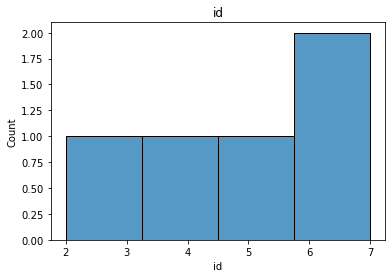

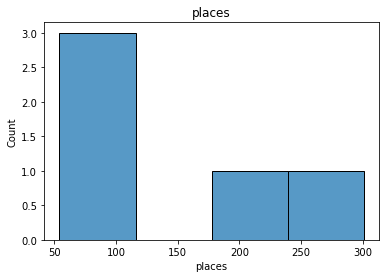

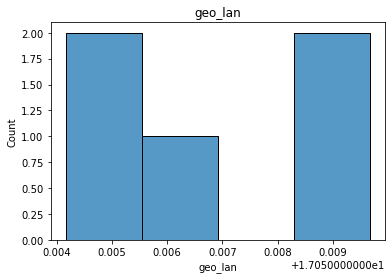

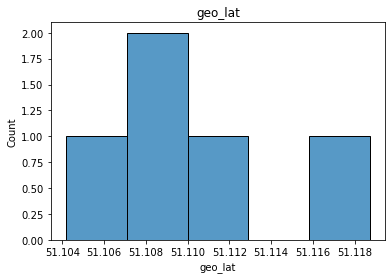

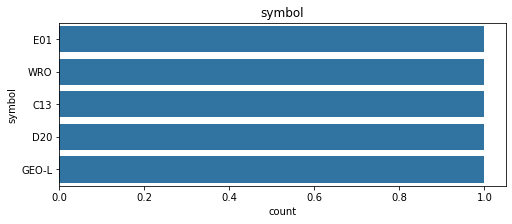

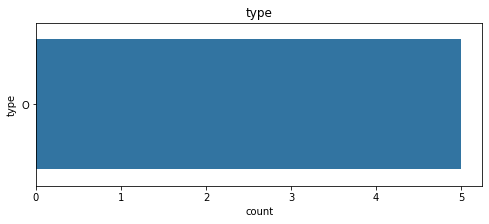

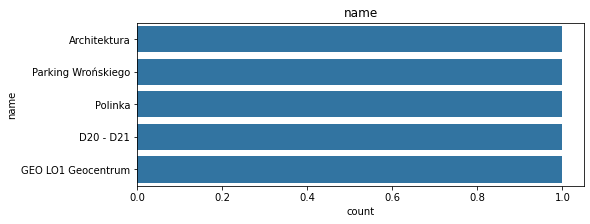

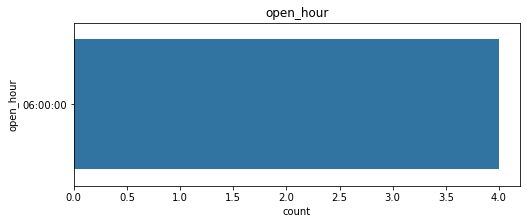

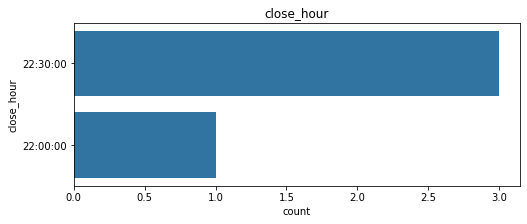

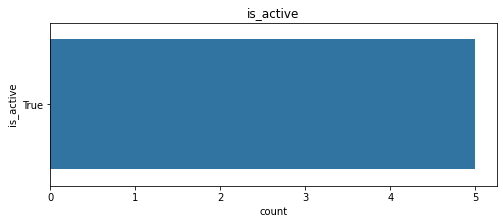

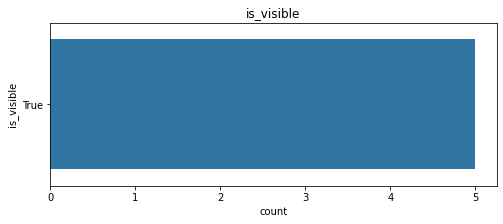

) missing from current font.es/IPython/core/pylabtools.py:151: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


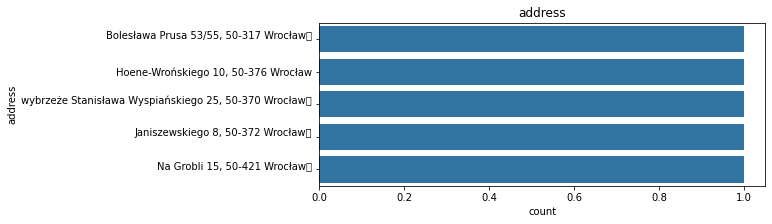

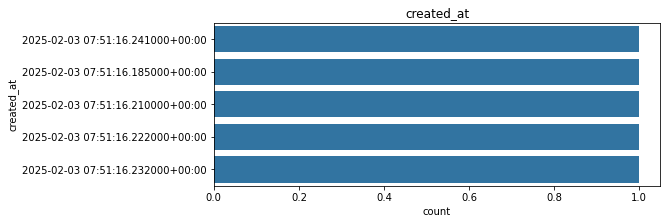

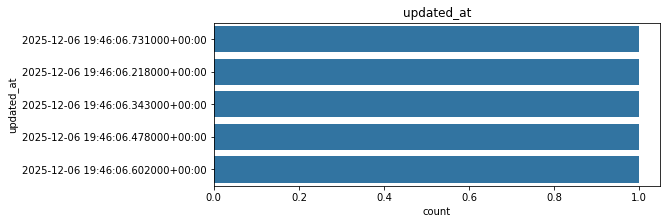

In [30]:
df_plot(parkings)

In [ ]:
# Relationship between parking data
print("Parking details:")
print(parkings[['id', 'name', 'places', 'address']].to_string())
print(f"\nAll parkings are active: {parkings['is_active'].all()}")
print(f"All parkings are visible: {parkings['is_visible'].all()}")

---
## pwr_events

In [47]:
pwr_events = pd.read_parquet(DATA_PATH / "pwr_events.parquet")
pwr_events.head()

,uid,summary,start,end,location
0,64etqju29vmbvvmfnrdrdcbce1@google.com,Dzień Studenta na W-6,2023-11-17 00:00:00+00:00,2023-11-18 00:00:00+00:00,
1,6th3id9p68p6abb160s66b9k6gqmabb1c9i38bb3cphjeo...,[Studencka Dawka Kultury] Wyjście na Fantastyc...,2018-11-16 18:00:00+00:00,2018-11-16 21:00:00+00:00,
2,3molmc2sfn4jbhi8j55gjnrgfs@google.com,II Wrocławskie Studenckie Sympozjum Chemiczne...,2013-04-13 08:00:00+00:00,2013-04-13 16:00:00+00:00,
3,cdh3ec9pcpj30b9l74p6ab9k6oo3ibb16ss38bb568rj2c...,ATP,2019-10-15 00:00:00+00:00,2019-10-17 00:00:00+00:00,
4,5e5mi83jagqmb7iarfb593pmjh@google.com,Mikołajki W7 - cukierki na kampusie,2017-12-06 00:00:00+00:00,2017-12-07 00:00:00+00:00,


In [32]:
pwr_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065 entries, 0 to 1064
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype              
---  ------    --------------  -----              
 0   uid       1065 non-null   object             
 1   summary   1065 non-null   object             
 2   start     1065 non-null   datetime64[ns, UTC]
 3   end       1065 non-null   datetime64[ns, UTC]
 4   location  1065 non-null   object             
dtypes: datetime64[ns, UTC](2), object(3)
memory usage: 41.7+ KB


In [33]:
pwr_events.isna().sum()

uid         0
summary     0
start       0
end         0
location    0
dtype: int64

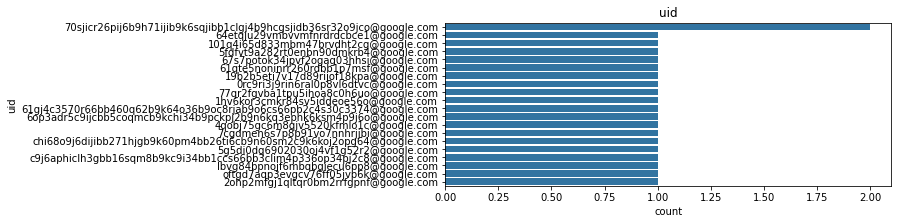

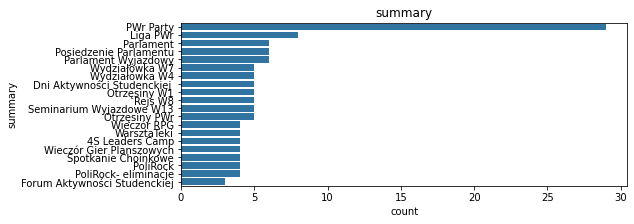

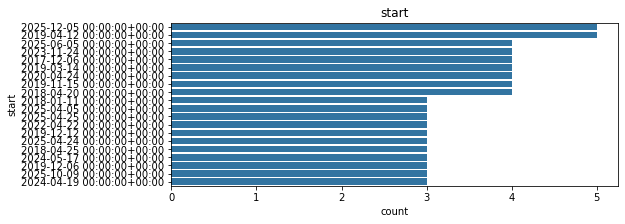

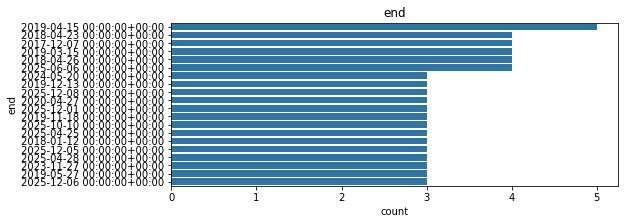

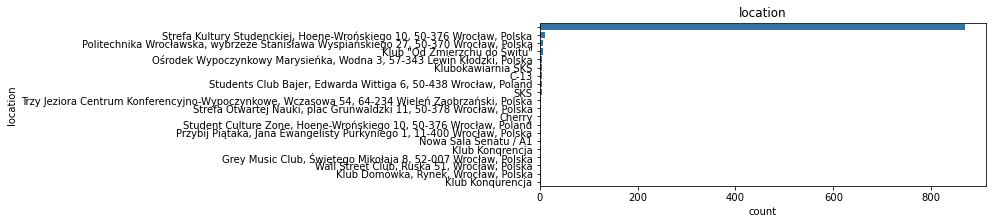

In [34]:
df_plot(pwr_events)

---
## sks_users

In [46]:
sks_users = pd.read_parquet(DATA_PATH / "sks_users.parquet")
sks_users.head()

,external_timestamp,active_users,moving_average_21,created_at,updated_at
0,2025-02-03 05:25:00+00:00,1,0,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00
1,2025-02-03 05:30:00+00:00,1,1,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00
2,2025-02-03 05:35:00+00:00,2,1,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00
3,2025-02-03 05:40:00+00:00,2,1,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00
4,2025-02-03 05:45:00+00:00,3,1,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00


In [36]:
sks_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77631 entries, 0 to 77630
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   external_timestamp  77631 non-null  datetime64[ns, UTC]
 1   active_users        77631 non-null  int64              
 2   moving_average_21   77631 non-null  int64              
 3   created_at          77631 non-null  datetime64[ns, UTC]
 4   updated_at          77631 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](3), int64(2)
memory usage: 3.0 MB


In [37]:
sks_users.isna().sum()

external_timestamp    0
active_users          0
moving_average_21     0
created_at            0
updated_at            0
dtype: int64

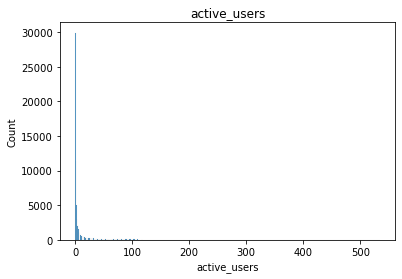

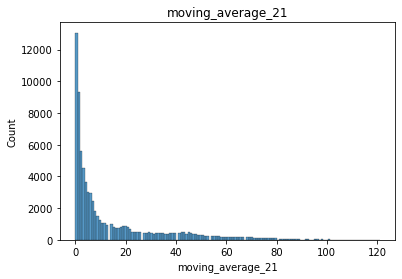

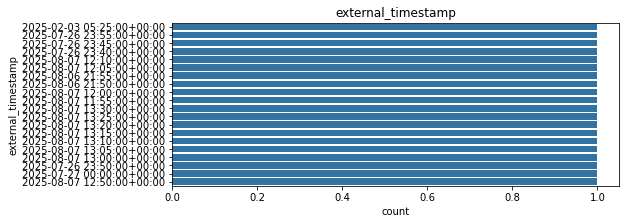

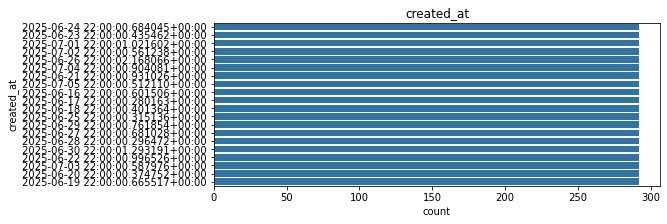

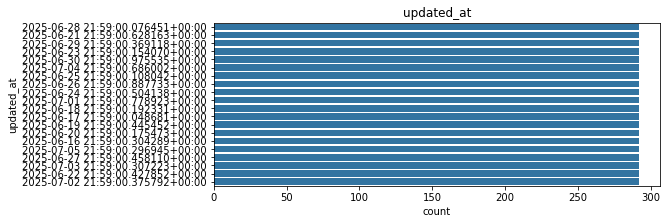

In [38]:
df_plot(sks_users)